Section 1: Import Libraries

In [128]:

# Section 1 : Import Libraries


# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Save Model
import joblib



Section 2: Load Dataset and Inspect data

In [129]:
train_df = pd.read_csv("../data/train_u6lujuX_CVtuZ9i.csv")
test_df = pd.read_csv("../data/test_Y3wMUE5_7gLdaTN.csv")

In [130]:
print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

Train Shape : (614, 13)
Test Shape  : (367, 12)


In [131]:
# First 5 Rows
train_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [132]:
#datasetinformation
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [133]:
#datatypes
train_df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [134]:
#stastical summary
train_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [135]:
#missing values
train_df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [136]:
#duplicate rows
print("Duplicate Rows:", train_df.duplicated().sum())

Duplicate Rows: 0


In [137]:
#unique values
train_df.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [138]:
#target variable distribution
train_df["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [139]:
#target variable percentage
(train_df["Loan_Status"].value_counts(normalize=True) * 100).round(2)

Loan_Status
Y    68.73
N    31.27
Name: proportion, dtype: float64

Section 3: Data Cleaning

In [140]:
# Make a copy
train_df = train_df.copy()
test_df = test_df.copy()

In [141]:
# Rename columns
train_df.columns = train_df.columns.str.lower().str.strip().str.replace(" ", "_")
test_df.columns = test_df.columns.str.lower().str.strip().str.replace(" ", "_")

train_df.columns

Index(['loan_id', 'gender', 'married', 'dependents', 'education',
       'self_employed', 'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area', 'loan_status'],
      dtype='object')

In [142]:
# Missing Values Count
train_df.isnull().sum()

loan_id               0
gender               13
married               3
dependents           15
education             0
self_employed        32
applicantincome       0
coapplicantincome     0
loanamount           22
loan_amount_term     14
credit_history       50
property_area         0
loan_status           0
dtype: int64

In [143]:
#missing value percentage
missing_percentage = (train_df.isnull().sum() / len(train_df) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Values": train_df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_df

,Missing Values,Percentage
loan_id,0,0.00
gender,13,2.12
married,3,0.49
dependents,15,2.44
education,0,0.00
self_employed,32,5.21
applicantincome,0,0.00
coapplicantincome,0,0.00
loanamount,22,3.58
loan_amount_term,14,2.28


In [144]:
#remove duplicate rows
print("Duplicate Rows Before:", train_df.duplicated().sum())

train_df.drop_duplicates(inplace=True)

print("Duplicate Rows After :", train_df.duplicated().sum())

Duplicate Rows Before: 0
Duplicate Rows After : 0


In [145]:
#drop loan_id
train_df.drop(columns="loan_id", inplace=True)
test_df.drop(columns="loan_id", inplace=True)

In [146]:
# Handle Missing Values
# Categorical Columns → Fill with Mode

categorical_cols = [
    "gender",
    "married",
    "dependents",
    "self_employed"
]

for col in categorical_cols:
    train_df[col].fillna(train_df[col].mode()[0], inplace=True)
    test_df[col].fillna(train_df[col].mode()[0], inplace=True)

In [147]:
# Numerical Columns → Fill with Median

numerical_cols = [
    "loanamount",
    "loan_amount_term",
    "credit_history"
]

for col in numerical_cols:
    median_value = train_df[col].median()

    train_df[col].fillna(median_value, inplace=True)
    test_df[col].fillna(median_value, inplace=True)

In [148]:
# Verify Missing Values
print("Train Missing Values")
print(train_df.isnull().sum())

print("\nTest Missing Values")
print(test_df.isnull().sum())

Train Missing Values
gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
loan_status          0
dtype: int64

Test Missing Values
gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
dtype: int64


In [149]:
print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

Train Shape : (614, 12)
Test Shape  : (367, 11)


Section 4: Exploratory Data Analysis (EDA)

Text(0.5, 1.0, 'Loan Status Distribution')

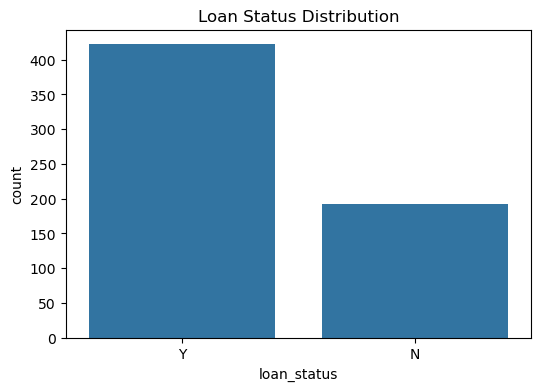

In [150]:
# 1. Loan Status Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="loan_status")
plt.title("Loan Status Distribution")

Text(0.5, 1.0, 'Credit History vs Loan Status')

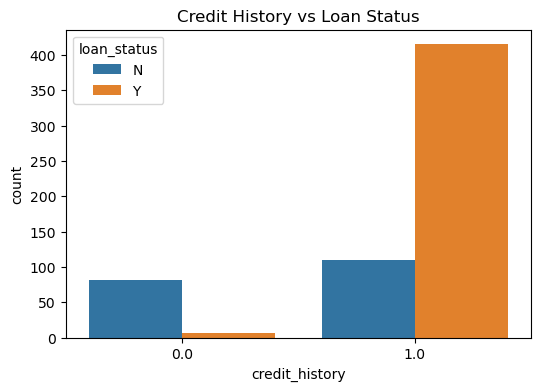

In [151]:
#2. Credit History vs Loan Status
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="credit_history", hue="loan_status")
plt.title("Credit History vs Loan Status")

Text(0.5, 1.0, 'Property Area vs Loan Status')

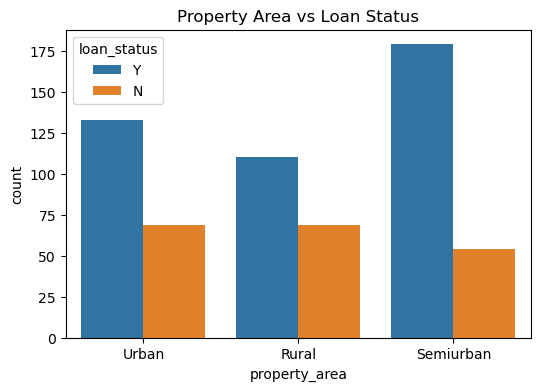

In [152]:
# 3. Property Area vs Loan Status
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="property_area", hue="loan_status")
plt.title("Property Area vs Loan Status")

Text(0.5, 1.0, 'Applicant Income Distribution')

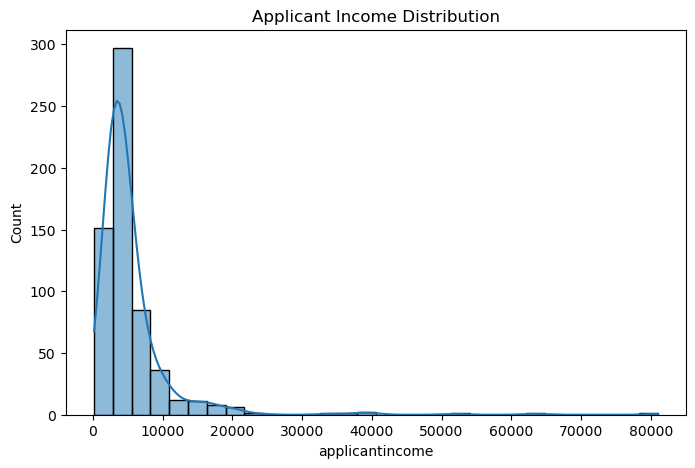

In [153]:
# 4. Applicant Income Distribution
plt.figure(figsize=(8,5))
sns.histplot(data=train_df, x="applicantincome", bins=30, kde=True)
plt.title("Applicant Income Distribution")

Text(0.5, 1.0, 'Loan Amount Distribution')

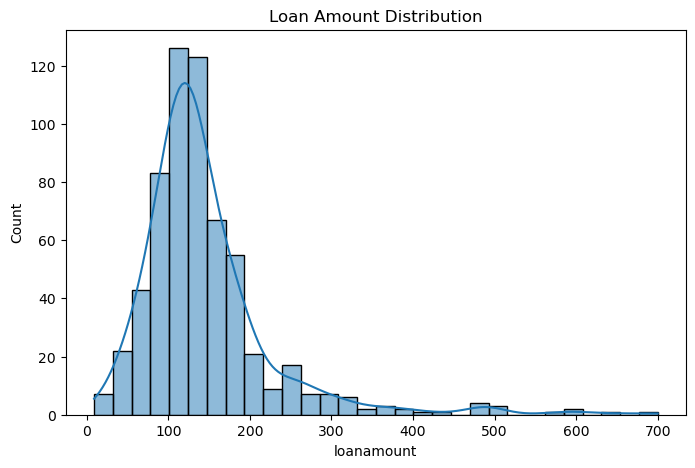

In [154]:
# 5. Loan Amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(data=train_df, x="loanamount", bins=30, kde=True)
plt.title("Loan Amount Distribution")

Text(0.5, 1.0, 'Loan Amount Boxplot')

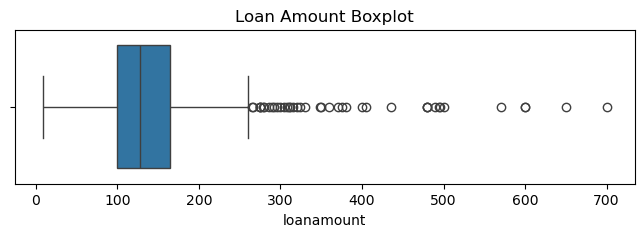

In [155]:
#6.Loan Amount Boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=train_df["loanamount"])
plt.title("Loan Amount Boxplot")

Text(0.5, 1.0, 'Correlation Heatmap')

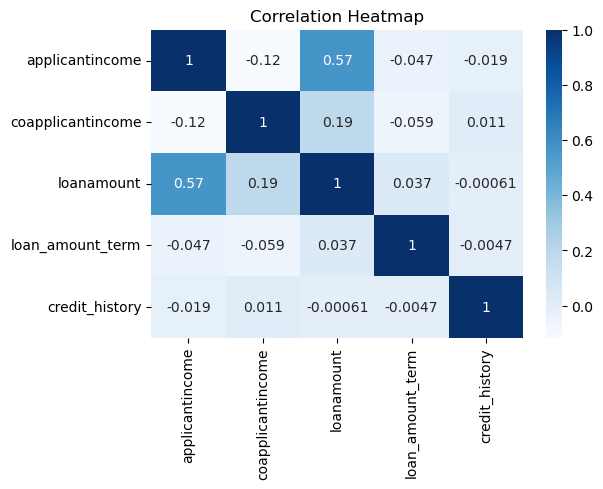

In [156]:
# 7.correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(train_df.select_dtypes(include="number").corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")

Section 5: Feature Engineering

In [157]:
# Total Income
train_df["total_income"] = train_df["applicantincome"] + train_df["coapplicantincome"]
test_df["total_income"] = test_df["applicantincome"] + test_df["coapplicantincome"]

# Log Transformation
train_df["loanamount_log"] = np.log1p(train_df["loanamount"])
test_df["loanamount_log"] = np.log1p(test_df["loanamount"])

train_df["total_income_log"] = np.log1p(train_df["total_income"])
test_df["total_income_log"] = np.log1p(test_df["total_income"])

In [158]:
train_df[["applicantincome", "coapplicantincome", "total_income"]].head()

,applicantincome,coapplicantincome,total_income
0,5849,0.0,5849.0
1,4583,1508.0,6091.0
2,3000,0.0,3000.0
3,2583,2358.0,4941.0
4,6000,0.0,6000.0


In [159]:
train_df[["loanamount", "loanamount_log"]].head()

,loanamount,loanamount_log
0,128.0,4.859812
1,128.0,4.859812
2,66.0,4.204693
3,120.0,4.795791
4,141.0,4.955827


In [160]:
train_df[["total_income", "total_income_log"]].head()

,total_income,total_income_log
0,5849.0,8.674197
1,6091.0,8.714732
2,3000.0,8.006701
3,4941.0,8.505525
4,6000.0,8.699681


Section 6: Data Preprocessing

In [161]:

# Section 6: Data Preprocessing


# Encode Target
train_df["loan_status"] = train_df["loan_status"].map({"Y":1, "N":0})

# Encode Categorical Features
train_df["gender"] = train_df["gender"].map({"Male":1, "Female":0})
test_df["gender"] = test_df["gender"].map({"Male":1, "Female":0})

train_df["married"] = train_df["married"].map({"Yes":1, "No":0})
test_df["married"] = test_df["married"].map({"Yes":1, "No":0})

train_df["education"] = train_df["education"].map({"Graduate":1, "Not Graduate":0})
test_df["education"] = test_df["education"].map({"Graduate":1, "Not Graduate":0})

train_df["self_employed"] = train_df["self_employed"].map({"Yes":1, "No":0})
test_df["self_employed"] = test_df["self_employed"].map({"Yes":1, "No":0})

train_df["dependents"] = train_df["dependents"].map({"0":0, "1":1, "2":2, "3+":3})
test_df["dependents"] = test_df["dependents"].map({"0":0, "1":1, "2":2, "3+":3})

train_df["property_area"] = train_df["property_area"].map({"Rural":0, "Semiurban":1, "Urban":2})
test_df["property_area"] = test_df["property_area"].map({"Rural":0, "Semiurban":1, "Urban":2})

# Features and Target
x = train_df.drop("loan_status", axis=1)
y = train_df["loan_status"]

In [162]:
print(x.shape)
print(y.shape)

(614, 14)
(614,)


Section 7: Train-Test Split & Feature Scaling

In [163]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [164]:
#feature scaling
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [165]:
print(x_train.shape)
print(x_test.shape)

print(y_train.shape)
print(y_test.shape)

(491, 14)
(123, 14)
(491,)
(123,)


Section 8: Model Building & Training

In [166]:
#model building
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

In [167]:
#training
for name, model in models.items():
    model.fit(x_train, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


Section 9: Model Evaluation

In [168]:
results = []

for name, model in models.items():

    y_pred = model.predict(x_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_pred)
    })

results = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

print(results)

                 Model  Accuracy   ROC_AUC
0  Logistic Regression  0.861789  0.783591
2        Random Forest  0.845528  0.771827
1        Decision Tree  0.837398  0.765944
3    Gradient Boosting  0.804878  0.735139


In [169]:
#select best model
best_model_name = results["Model"].values[0]
best_model = models[best_model_name]

print("\nBest Model:", best_model_name)


Best Model: Logistic Regression


In [170]:
#predictions
y_pred = best_model.predict(x_test)

In [171]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
150,0,0
559,1,1
598,1,1
235,1,1
145,1,1
191,0,1
557,1,1
470,1,1
88,1,1
386,1,1


In [172]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))



Confusion Matrix
[[22 16]
 [ 1 84]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



Section 10: Save Model

In [173]:


joblib.dump(best_model, "../model/loan_model.pkl")
joblib.dump(scaler, "../model/scaler.pkl")

print("Model, Scaler  saved successfully.")

Model, Scaler  saved successfully.
